# ISLP chapter 3: linear regression from scratch

The objective of this notebook is to rebuild the first part of chapter 3 of *An Introduction to Statistical Learning* without using a library for the model. The estimates come from `easylearn`, the small package I am writing while going through the book, and scikit-learn is used only at the end, to check that our coefficients are correct.

The data is the `Advertising` dataset of the book: the sales of a product in 200 markets, together with the budget spent on TV, radio and newspaper advertising.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from easylearn.linear_model import LinearRegression

ad = pd.read_csv("../Data/ALL CSV FILES - 2nd Edition/Advertising.csv", index_col=0)   # notebook is in notebooks/, data one level up
print(ad.shape)
ad.head()

(200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3.1 Simple linear regression

We start from the simplest case, with one predictor (TV) and one response (sales). The model says that sales are, on average, a straight line of the TV budget,

$$\hat{y}_i = \beta_0 + \beta_1 x_i ,$$

and what is left between the observed value and the line is the residual, $e_i = y_i - \hat{y}_i$.

In order to choose the line we need a criterion. The one used in the book, the so called least squares, looks for the $\beta_0$ and $\beta_1$ that make the residual sum of squares as small as possible:

$$\text{RSS} = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 .$$

RSS is convex in the two coefficients, so the minimum is where both partial derivatives are zero:

$$\frac{\partial\,\text{RSS}}{\partial \beta_0} = -2 \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i) = 0, \qquad \frac{\partial\,\text{RSS}}{\partial \beta_1} = -2 \sum_{i=1}^{n} x_i (y_i - \beta_0 - \beta_1 x_i) = 0 .$$

Solving the two equations we get the closed form of equation 3.4:

$$\hat\beta_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}, \qquad \hat\beta_0 = \bar{y} - \hat\beta_1 \bar{x} .$$

Here we compute it directly with numpy.

In [2]:
x = ad["TV"].values
y = ad["sales"].values

beta_1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
beta_0 = y.mean() - beta_1 * x.mean()
beta_0, beta_1

(np.float64(7.0325935491276965), np.float64(0.047536640433019736))

With more than one predictor these formulas become heavy to write, so it is better to move to matrix notation. If we add a column of ones in front of the predictors we get the design matrix $X$, and all the coefficients come out of the normal equations:

$$\hat\beta = (X^\top X)^{-1} X^\top y .$$

This is what `LinearRegression` does inside `fit` in `easylearn`. Fitted on TV only, it has to give the same two numbers as the closed form above.

In [3]:
model = LinearRegression().fit(x, y)
model.intercept_, model.coef_[0]

(np.float64(7.032593549127698), np.float64(0.04753664043301972))

Now we can reproduce figure 3.1 of the book: sales against the TV budget, the least squares line, and in grey the residuals, which are the vertical distances that least squares minimizes once they are squared and summed.

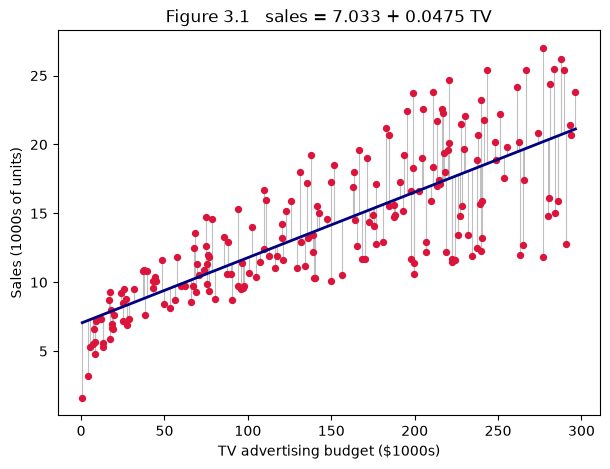

In [4]:
yhat = model.predict(x)

fig, ax = plt.subplots(figsize=(7, 5))
ax.vlines(x, yhat, y, color="0.75", lw=0.8, zorder=1)
ax.scatter(x, y, color="crimson", s=18, zorder=2)
order = np.argsort(x)
ax.plot(x[order], yhat[order], color="navy", lw=2, zorder=3)

ax.set_xlabel("TV advertising budget ($1000s)")
ax.set_ylabel("Sales (1000s of units)")
ax.set_title(f"Figure 3.1   sales = {model.intercept_:.3f} + {model.coef_[0]:.4f} TV")
plt.show()

The RSS of this line can be computed from its definition, and `easylearn` also has it as `rss_()`. The two numbers have to be the same.

In [5]:
e = y - yhat
rss_by_hand = np.sum(e ** 2)
rss_by_hand, model.rss_()

(np.float64(2102.5305831313517), np.float64(2102.5305831313517))

## 3.1.2 How accurate are the coefficients?

Now there is an important point to add: how accurate are our estimates? The betas we found are tied to this specific sample. Another sample drawn from the same population would have given different ones, very similar with high probability, but not the same. Keeping this in mind, we need to go from the estimate to some inference about it.

We start from the model $y = X\beta + \varepsilon$, where we treat $X$ as fixed, and we assume that the errors have mean zero and are uncorrelated with a common variance, $\operatorname{Var}(\varepsilon) = \sigma^2 I$. This last assumption is important, since the whole derivation below uses it.

From the normal equations, the estimator is a linear function of $y$: if we call $A = (X^\top X)^{-1} X^\top$, then $\hat\beta = A y$, and since $X$ is fixed also $A$ is a constant matrix. Substituting $y = X\beta + \varepsilon$:

$$\hat\beta = (X^\top X)^{-1} X^\top X \beta + A\varepsilon = \beta + A\varepsilon .$$

The errors have mean zero, so the estimator is unbiased, and all its variability comes from $A\varepsilon$. For a constant matrix the variance is $A \operatorname{Var}(\varepsilon) A^\top$, and since $A^\top = X (X^\top X)^{-1}$:

$$\operatorname{Var}(\hat\beta) = \sigma^2 A A^\top = \sigma^2 (X^\top X)^{-1} X^\top X (X^\top X)^{-1} = \sigma^2 (X^\top X)^{-1} .$$

On the diagonal of this matrix there are the variances of the single coefficients, and their square roots are the standard errors. The problem is that $\sigma^2$ is unknown, so we replace it with its unbiased estimate, $\hat\sigma^2 = \text{RSS}/(n - p - 1)$, where $p$ is the number of predictors:

$$\operatorname{SE}(\hat\beta_j) = \sqrt{\big[\hat\sigma^2 (X^\top X)^{-1}\big]_{jj}} .$$

Below we compute them by hand for the TV regression and we compare them with `se_coef_()`. The square root of $\hat\sigma^2$ is the residual standard error, which the book reports in table 3.2.

In [6]:
X = np.column_stack([np.ones(len(x)), x])          # design matrix with the intercept column
sigma2 = rss_by_hand / (len(y) - 2)                # n - p - 1, with p = 1
se_by_hand = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))

print("standard errors by hand:", se_by_hand)
print("easylearn se_coef_():   ", model.se_coef_())
print("residual standard error:", np.sqrt(sigma2))

standard errors by hand: [0.45784294 0.00269061]
easylearn se_coef_():    [0.45784294 0.00269061]
residual standard error: 3.258656368650463


## 3.2 Multiple linear regression

Everything above works also with more predictors without changing the code, since `easylearn` always goes through the design matrix. Here we regress sales on TV, radio and newspaper together, and `summary()` returns the coefficients with standard errors, t-statistics and p-values, which are the numbers of table 3.4 in the book.

In [7]:
full = LinearRegression().fit(ad[["TV", "radio", "newspaper"]], ad["sales"])
full.summary().round(4)

,coef,std err,t,P>|t|
intercept,2.9389,0.3119,9.4223,0.0000
TV,0.0458,0.0014,32.8086,0.0000
radio,0.1885,0.0086,21.8935,0.0000
newspaper,-0.0010,0.0059,-0.1767,0.8599


As a last step we check the coefficients against scikit-learn. It returns only the point estimates, without standard errors, which is fine for us: the goal is to be sure that our normal equations are right, not to take the inference from a library.

In [8]:
from sklearn.linear_model import LinearRegression as SkLinearRegression

sk = SkLinearRegression().fit(ad[["TV", "radio", "newspaper"]], ad["sales"])
print("same intercept:", np.allclose(sk.intercept_, full.intercept_))
print("same slopes:   ", np.allclose(sk.coef_, full.coef_))

same intercept: True
same slopes:    True


## Next steps

At the moment `easylearn` covers the coefficients and their standard errors. Eventually it will be interesting to add the rest of section 3.1.3, the $R^2$ and the residual standard error as methods of the class, and then the F-statistic of section 3.2, which the book uses to judge the model as a whole.